In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/fake_job_postings.csv")

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

Rows: 17880
Columns: 18
Shape: (17880, 18)


In [5]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- job_id
- title
- location
- department
- salary_range
- company_profile
- description
- requirements
- benefits
- telecommuting
- has_company_logo
- has_questions
- employment_type
- required_experience
- required_education
- industry
- function
- fraudulent


In [7]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [9]:
missing = df.isnull().sum()

print(missing)

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

In [12]:
missing_summary

,missing_count,missing_percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [14]:
print(df["fraudulent"].value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


## Understanding Important Columns

In [15]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

column_summary

,column,data_type,missing_count,missing_percentage,unique_values
job_id,job_id,int64,0,0.00,17880
title,title,object,0,0.00,11231
location,location,object,346,1.94,3105
department,department,object,11547,64.58,1337
salary_range,salary_range,object,15012,83.96,874
company_profile,company_profile,object,3308,18.50,1709
description,description,object,1,0.01,14801
requirements,requirements,object,2696,15.08,11967
benefits,benefits,object,7212,40.34,6204
telecommuting,telecommuting,int64,0,0.00,2


In [16]:
target_counts = df["fraudulent"].value_counts().sort_index()

In [17]:
target_counts

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [18]:
target_percent = (
    df["fraudulent"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_percent

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

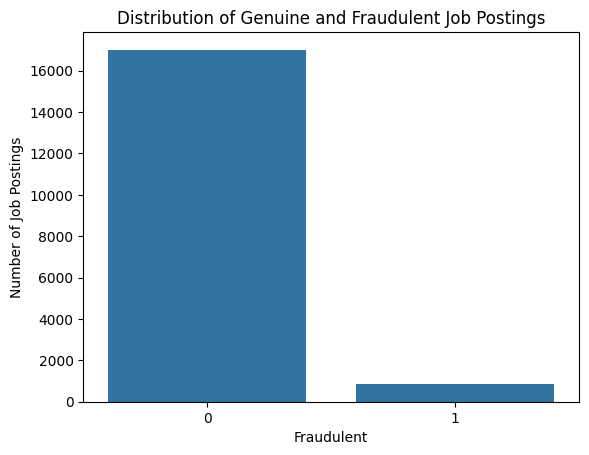

In [20]:
sns.countplot(data=df, x="fraudulent")
plt.title("Distribution of Genuine and Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")
plt.show()

In [21]:
target_labels = df["fraudulent"].map({
    0: "Genuine",
    1: "Fraudulent"
})

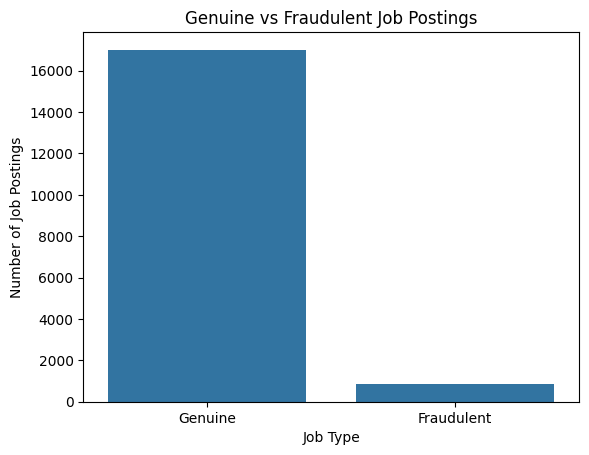

In [22]:
sns.countplot(x=target_labels)

plt.title("Genuine vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.show()

In [23]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for col in binary_columns:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df[col],
            df["fraudulent"],
            normalize="index"
        ).round(3)
    )


--- telecommuting ---
fraudulent         0      1
telecommuting              
0              0.953  0.047
1              0.917  0.083

--- has_company_logo ---
fraudulent            0      1
has_company_logo              
0                 0.841  0.159
1                 0.980  0.020

--- has_questions ---
fraudulent         0      1
has_questions              
0              0.932  0.068
1              0.972  0.028


In [24]:
columns_to_check = [
    "salary_range",
    "company_profile",
    "requirements",
    "benefits",
    "location",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in columns_to_check:
    missing_rate = (
        df.groupby(df[col].isna())["fraudulent"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(f"\n--- {col} ---")
    print(missing_rate)


--- salary_range ---
salary_range
False    7.78
True     4.28
Name: fraudulent, dtype: float64

--- company_profile ---
company_profile
False     1.91
True     17.74
Name: fraudulent, dtype: float64

--- requirements ---
requirements
False    4.69
True     5.71
Name: fraudulent, dtype: float64

--- benefits ---
benefits
False    4.71
True     5.05
Name: fraudulent, dtype: float64

--- location ---
location
False    4.83
True     5.49
Name: fraudulent, dtype: float64

--- employment_type ---
employment_type
False    4.34
True     6.94
Name: fraudulent, dtype: float64

--- required_experience ---
required_experience
False    3.98
True     6.17
Name: fraudulent, dtype: float64

--- required_education ---
required_education
False    4.25
True     5.56
Name: fraudulent, dtype: float64

--- industry ---
industry
False    4.55
True     5.61
Name: fraudulent, dtype: float64

--- function ---
function
False    4.63
True     5.22
Name: fraudulent, dtype: float64
